
# Fine-tuning IndicWav2Vec for Bhojpuri ASR

## Purpose
This notebook fine-tunes a pretrained **IndicWav2Vec** automatic speech recognition (ASR) model on the Bhojpuri subset of the SpeeD-IA corpus. It implements the adaptation pipeline described in the dissertation.

---

## What this notebook produces
Running this notebook end-to-end will generate:

- A fine-tuned ASR model checkpoint and final trained model
- Associated processor/tokenizer artifacts
- Training logs and evaluation metrics (WER and CER)

All outputs are written to a single experiment directory specified in the configuration section.

---

## Experimental usage (important)

This notebook is designed to be executed **multiple times**, with different configuration settings, in order to produce the set of adapted models analysed in the dissertation.  
Each run corresponds to a distinct experimental condition, including:

- Different proportions of labelled training data (e.g. one-third, two-thirds, and full dataset)
- Alternative acoustic augmentation settings
- Tokenizer adaptation and language-model-assisted decoding (KenLM)
- Combinations of the above adaptations

For each experimental variant, the configuration parameters (e.g. data subset size, augmentation flags, tokenizer and KenLM settings) and the output directory must be updated accordingly.  
This ensures that models and results from different runs are stored separately and can be traced unambiguously to the corresponding experimental setup.

---

## How to run
Run the notebook **top to bottom** without skipping cells.

The notebook is organised into the following stages:
1. Setup (Colab)  
2. Setup & config  
3. Utility functions (definitions only)  
4. Data loading + internal train/val split  
5. Preprocessing + augmentations (train-only)  
6. Tokenizer / KenLM (optional)  
7. Fine-tuning  
8. Evaluation + saving artifacts  

**Expected runtime (on Google Colab, T4 / A100 GPU):**
- Setup and data loading: 5–10 minutes  
- Fine-tuning: 20–120 minutes (depending on data size, augmentation strategy, tokenizer and KenLM integration, and number of epochs)  

---

## Assumptions and requirements

- **Data location:**  
  The Bhojpuri subset of the SpeeD-IA corpus is available locally and its path is specified via `DATA_DIR` in the configuration section. Dataset splits are created **outside this notebook** (see the separate data-splitting and analysis notebook). This notebook loads the **pre-defined trainval split** (i.e., all data available for training and model selection)  
  The SpeeD-IA dataset can be downloaded from: https://github.com/kmi-linguistics/SpeeD-IA

- **Hardware:**  
  A GPU is required for fine-tuning. The notebook is tested on Google Colab with CUDA-enabled GPUs.

- **Software environment:**  
  Python ≥ 3.9 with PyTorch, Hugging Face Transformers, Datasets, and related ASR dependencies installed (see Setup section).

- **Hugging Face access:**  
  This notebook loads a gated pretrained model and requires Hugging Face authentication before execution.
No access token is stored or hard-coded in this notebook. Refer to the documentation later in this notebook for authentication instructions.

---





# 1. Setup (Colab)

This notebook uses dependencies that are installed at runtime in Colab.
**Important:** If installation updates NumPy / core libraries, the runtime may restart.
After restart, rerun the notebook from the top.


In [1]:
# --- Install dependencies (Colab) ---
# This cell installs all required system and Python packages.
# If core libraries or compiled extensions are installed, a runtime restart is required.

import sys, subprocess, pkgutil, importlib.util
from pathlib import Path
from packaging import version

def run(cmd):
    print(" ".join(cmd))
    subprocess.check_call(cmd)

needs_restart = False

# -------------------------------------------------
# 1) NumPy < 2.0 workaround (critical)
# -------------------------------------------------
try:
    import numpy as np
    if version.parse(np.__version__) >= version.parse("2.0.0"):
        print(f"NumPy {np.__version__} detected (>=2.0). Downgrading...")
        run([sys.executable, "-m", "pip", "install", "-q", "numpy<2.0"])
        needs_restart = True
    else:
        print(f"NumPy OK: {np.__version__}")
except Exception:
    run([sys.executable, "-m", "pip", "install", "-q", "numpy<2.0", "packaging"])
    needs_restart = True

# -------------------------------------------------
# 2) torchcodec (CUDA-specific wheel)
# -------------------------------------------------
print("Installing torchcodec (CUDA 12.6)...")
run([
    sys.executable, "-m", "pip", "install", "-q",
    "torchcodec",
    "--index-url", "https://download.pytorch.org/whl/cu126"
])

# -------------------------------------------------
# 3) Python dependencies
# -------------------------------------------------
PYTHON_PACKAGES = [
    "datasets",
    "evaluate",
    "jiwer",
    "pyctcdecode",
    "textgrid"
]

print("Installing Python packages...")
run([sys.executable, "-m", "pip", "install", "-q"] + PYTHON_PACKAGES)

# -------------------------------------------------
# 4) KenLM (build from source)
# -------------------------------------------------

kenlm_installed = importlib.util.find_spec("kenlm") is not None

if not kenlm_installed:
    !apt-get install -y build-essential libbz2-dev liblzma-dev zlib1g-dev
    !pip install git+https://github.com/kpu/kenlm.git
    import kenlm
    needs_restart = True
else:
    print("KenLM already installed. Skipping installation.")


# -------------------------------------------------
# 5) Restart notice
# -------------------------------------------------
if needs_restart:
    print("\n===================================================")
    print("IMPORTANT: Runtime restart required.")
    print("Please restart the runtime now:")
    print("  Runtime → Restart runtime")
    print("Then rerun the notebook from the top.")
    print("===================================================\n")


NumPy OK: 1.26.4
Installing torchcodec (CUDA 12.6)...
/usr/bin/python3 -m pip install -q torchcodec --index-url https://download.pytorch.org/whl/cu126
Installing Python packages...
/usr/bin/python3 -m pip install -q datasets evaluate jiwer pyctcdecode textgrid
KenLM already installed. Skipping installation.


# 2. Setup & configuration


## Environment and versions

This notebook has been tested with the following software environment.  
Exact versions are logged at runtime to support reproducibility.


In [2]:

import transformers
import datasets
import platform
import glob, os
import torchaudio
import librosa.display
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, Wav2Vec2FeatureExtractor, Wav2Vec2CTCTokenizer
import torch
from jiwer import wer, cer#
import pandas as pd
import matplotlib.patches as mpatches
import numpy as np
import re
import json
import torchaudio
from IPython.display import Audio
import soundfile as sf
import random
import textgrid
from datasets import Dataset, DatasetDict, load_from_disk
import evaluate
from tqdm import tqdm
from transformers import pipeline
from transformers import (
AutomaticSpeechRecognitionPipeline,
WhisperTimeStampLogitsProcessor,
WhisperForConditionalGeneration,
WhisperTokenizer,
WhisperProcessor,
)
from transformers import (AutoProcessor, AutoModelForCTC, Trainer, TrainingArguments)
from transformers import DataCollatorWithPadding
from collections import Counter
from transformers import EarlyStoppingCallback
import importlib.util
import subprocess
import sys
import torch.nn as nn
import torch.nn.functional as F
from pyctcdecode import build_ctcdecoder
from typing import Any, Dict, List, Union
from torch.optim import AdamW



print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)
print("NumPy:", np.__version__)


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
PyTorch: 2.9.0+cu126
CUDA available: True
Transformers: 4.57.3
NumPy: 1.26.4


In [3]:
# --- Optional: Google Drive mount (Colab only) ---
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Not running in Colab; skipping Drive mount.")


Mounted at /content/drive
Google Drive mounted.


## Paths and outputs

All input and output paths are defined in one place to improve portability.
The notebook does not assume a fixed directory structure or Google Drive layout.


In [4]:
from pathlib import Path

# Root project directory (change if running locally)
PROJECT_DIR = Path(".").resolve()

# Data directory (SpeeD-IA Bhojpuri subset)
DATA_DIR = PROJECT_DIR / "drive/My Drive/ASR/01_Data/lifecycle_split_LOSO"

# Output directory for this experiment
OUTPUT_DIR = PROJECT_DIR / "drive/My Drive/ASR"

# Subdirectories
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: /content
DATA_DIR: /content/drive/My Drive/ASR/01_Data/lifecycle_split_LOSO
OUTPUT_DIR: /content/drive/My Drive/ASR


## Experiment configuration

This section defines all experiment-level flags and hyperparameters.
These values control model selection, data filtering, augmentation, and training.
They should be modified **only here** to keep the experiment reproducible.


In [5]:
CONFIG = {
    # Model
    "model_id": "ai4bharat/indicwav2vec-hindi",
    "sample_rate": 16_000,

    # Data filtering
    "min_duration_sec": 3.0,

    # Training
    "per_device_train_batch_size": 2,
    "gradient_checkpointing": True,
    "eval_steps": 1000,
    "num_train_epochs": 15,
    "train_batch_size": 8,
    "eval_batch_size": 8,
    "gradient_accumulation_steps": 2,
    "learning_rate": 3e-4,
    "warmup_steps": 500,
    "fp16": True,
    "logging_steps": 1000,
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "eval_strategy": "epoch",
    "seed": 42,

    #train data size
    "train_data_size": 1.0, # e.g. 1.0 for full and 0.33 for 1/3rd

    # Augmentation flags
    "vtlp": True,
    "specaugment": True,
    "time_stretch": False,

    # Tokenizer / decoding
    "tokenizer": True,
    "kenlm": True,
    "kenlm_build": False, #used one-off to build the 3-gram model

    # Evaluation
    "compute_cer": True,
}


The active configuration for this run is printed below to make experimental
choices explicit and auditable.


# 3. Utility functions (used throughout)

This section defines helper functions for:
- loading and filtering the dataset
- audio/text preprocessing
- augmentation operations (train-only)
- decoding and metric computation

In [6]:
# Load dataset from folders
def extract_transcript_from_textgrid(textgrid_path):
    """
    Extract the transcription text from a Praat TextGrid file.

    This function reads the first tier of the TextGrid and concatenates
    all non-empty interval labels to form the utterance-level transcript.
    """
    tg = textgrid.TextGrid.fromFile(textgrid_path)
    tier = tg.tiers[0]
    return " ".join(
        interval.mark.strip()
        for interval in tier.intervals
        if interval.mark.strip()
    )

In [7]:
# Filter out records where audio array is empty
def filter_non_empty_audio(sample):
    """
    Filter out dataset entries with missing or empty audio data.

    This function ensures that only samples containing valid audio arrays
    are retained for training and evaluation.
    """
    return sample.get("audio") is not None and len(sample["audio"]["array"]) > 0


In [8]:
# Load audio
def load_audio(path):
    """
    Load an audio file and resample it to 16 kHz if required.

    This function ensures a consistent sampling rate for all audio inputs
    prior to feature extraction and model processing.
    """
    waveform, sr = torchaudio.load(path)
    if sr != 16000:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sr,
            new_freq=16000
        )
        waveform = resampler(waveform)
    return waveform

In [9]:
def prepare_dataset(batch):
    """
    Prepare a single dataset example for CTC-based ASR training.

    This function converts a raw audio–text pair into model-ready inputs by:
    (i) extracting logit-ready input values from the waveform using the shared processor, and
    (ii) encoding the corresponding transcription into label IDs for CTC training.

    """
    audio = batch["audio"]
    batch["input_values"] = processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_values[0]
    batch["labels"] = processor(
        text=batch["transcription"]
    ).input_ids
    return batch


In [10]:
def clean_prediction(text: str) -> str:
    """
    Clean special tokens from a decoded prediction string.

    This function removes start/end sentence markers and trims
    surrounding whitespace before evaluation.
    """
    return text.replace("<s>", "").replace("</s>", "").strip()


In [11]:
import multiprocessing as mp

def compute_metrics(pred):
    """
    Compute evaluation metrics for ASR predictions during training.

    This function decodes model outputs into text, optionally applying
    KenLM-based beam search decoding, and computes Word Error Rate (WER)
    against the reference transcripts.
    """
    if CONFIG["kenlm"]:
        logits = pred.predictions

        # Convert to list-of-arrays format expected by the decoder
        logits_list = [logits for logits in logits]

        pool = mp.Pool(processes=4)
        pred_str = decoder.decode_batch(
            pool,
            logits_list,
            beam_width=5
        )
        pool.close()
        pool.join()

        pred_str = [clean_prediction(text) for text in pred_str]
    else:
        pred_ids = pred.predictions.argmax(-1)
        pred_str = processor.batch_decode(pred_ids)

    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(
        pred.label_ids,
        group_tokens=False
    )

    # Log a small number of examples for inspection
    for i in range(2):
        print(f"\nPREDICTED: {pred_str[i]}")
        print(f"REFERENCE: {label_str[i]}")

    return {
        "wer": wer_metric.compute(
            predictions=pred_str,
            references=label_str
        )
    }


In [12]:
def apply_vtlp_waveform(waveform, sample_rate=16000, factor=1.5):
    """
    Apply Voice Tract Length Perturbation using Torch

    """
    # Ensure input is a tensor (convert from numpy if needed)
    if isinstance(waveform, np.ndarray):
        waveform = torch.from_numpy(waveform).float()

    # Compute new "virtual" sample rate
    new_sample_rate = int(sample_rate * factor)

    # Resample up/down, then back to original rate
    stretched_waveform = torchaudio.functional.resample(waveform, sample_rate, new_sample_rate)
    restored_waveform = torchaudio.functional.resample(stretched_waveform, new_sample_rate, sample_rate)

    return restored_waveform


In [13]:
def time_stretch_preserve_pitch(waveform, sample_rate=16000, stretch_factor=1.5):
    """
    Time-stretch audio without changing pitch.

    stretch_factor > 1.0 → slower
    stretch_factor < 1.0 → faster
    """
    # Convert torch tensor to numpy
    y = waveform

    # Apply time-stretch (preserves pitch)
    y_stretched = librosa.effects.time_stretch(y, rate=1.0 / stretch_factor)  # stretch by inverse

    # Convert back to torch tensor
    return torch.tensor(y_stretched, dtype=torch.float32)

In [14]:
# Compute Log Mel
def compute_log_mel(waveform, sr=16000, n_mels=80):
    """
    Converts raw waveform into log-mel form

    """
    mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=n_mels)
    return librosa.power_to_db(mel, ref=np.max)


In [15]:
# Plot spectrogram side by side for audio before and after applying the sugmentation
def plot_spectrogram_side_by_side(audio_data_original, audio_data_aug, title="Augmented"):
    """
    Plot spectrograms for original and augmented audio, side by side

    """
    # Create 2x2 subplots (2 audio files × 2 versions: Original & VTLP)
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f'Original vs {title} Log-Mel Spectrograms', fontsize=16)

    # Plot spectrograms
    for i in range(2):  # Plot for the first 2 files
        # Original
        waveform_orig = audio_data_original[i]["audio"]["array"]
        spec_orig = compute_log_mel(waveform_orig)

        ax_orig = axes[i][0]
        librosa.display.specshow(spec_orig, sr=16000, x_axis='time', y_axis='mel', ax=ax_orig)
        ax_orig.set_title(f'Original Audio {i+1}')
        ax_orig.label_outer()

        # VTLP Augmented
        waveform_aug = audio_data_aug[i]["audio"]["array"]
        spec_aug = compute_log_mel(waveform_aug)

        ax_aug = axes[i][1]
        librosa.display.specshow(spec_aug, sr=16000, x_axis='time', y_axis='mel', ax=ax_aug)
        ax_aug.set_title(f'Augmented Audio {i+1}')
        ax_aug.label_outer()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [16]:
# Randomly mask a segment of the waveform (i.e., set samples to zero)
def apply_time_mask_waveform(waveform, mask_duration_ms=150, sample_rate=16000):
    """
    Apply time-domain masking to a waveform.

    This function randomly selects a short temporal segment of the audio
    and sets its samples to zero to simulate missing or corrupted signal
    regions during training.
    """
    mask_duration = int((mask_duration_ms / 1000) * sample_rate)
    start = np.random.randint(0, len(waveform) - mask_duration)
    waveform[start:start + mask_duration] = 0.0
    return waveform.astype(np.float32)


In [17]:
import scipy.signal

def apply_amplitude_mask_waveform(
    waveform,
    low_freq=200,
    high_freq=400,
    sample_rate=16000
):
    """
    Apply band-stop filtering to a waveform as an amplitude masking operation.

    This function attenuates a specified frequency band to simulate
    spectral distortion or channel effects during training.
    """
    sos = scipy.signal.butter(
        10,
        [low_freq, high_freq],
        btype="bandstop",
        fs=sample_rate,
        output="sos"
    )
    filtered_waveform = scipy.signal.sosfilt(sos, waveform)
    return filtered_waveform.astype(np.float32)



In [18]:
# Waveform-space SpecAugment-inspired masking
# Simulates time masking and frequency masking directly on the waveform
def apply_specaugment_like_waveform(waveform, sample_rate=16000):
    """
    Apply SpecAugment-inspired masking operations in waveform space.

    This function sequentially applies time-domain masking and
    frequency-band attenuation to increase robustness during training.
    """
    waveform = apply_time_mask_waveform(
        waveform,
        sample_rate=sample_rate
    )
    waveform = apply_amplitude_mask_waveform(
        waveform,
        sample_rate=sample_rate
    )
    return waveform



In [19]:
def augment_data(data, aug_type):
    """
    Apply a specified waveform-level augmentation to a dataset.

    This function generates augmented audio samples using a selected
    augmentation strategy while preserving the original transcriptions.
    """
    aug_data = []
    total_duration = 0.0

    if aug_type == "time_stretched":
        for sample in data:
            time_stretched_wf = time_stretch_preserve_pitch(
                sample["audio"]["array"],
                sample_rate=16000,
                stretch_factor=1.5
            )
            aug_data.append({
                "path": sample["path"],
                "transcription": sample["transcription"],
                "audio": {
                    "array": time_stretched_wf,
                    "sampling_rate": 16000
                }
            })
            total_duration += time_stretched_wf.shape[-1] / 16000

    elif aug_type == "vtlp":
        for sample in data:
            augmented_waveform = apply_vtlp_waveform(
                sample["audio"]["array"],
                sample_rate=16000,
                factor=0.66
            )
            aug_data.append({
                "path": sample["path"],
                "transcription": sample["transcription"],
                "audio": {
                    "array": augmented_waveform,
                    "sampling_rate": 16000
                }
            })
            total_duration += augmented_waveform.shape[-1] / 16000

    elif aug_type == "specaug":
        for sample in data:
            augmented_waveform = apply_specaugment_like_waveform(
                sample["audio"]["array"]
            )
            aug_data.append({
                "path": sample["path"],
                "transcription": sample["transcription"],
                "audio": {
                    "array": augmented_waveform,
                    "sampling_rate": 16000
                }
            })
            total_duration += augmented_waveform.shape[-1] / 16000

    return aug_data, total_duration


In [20]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator for CTC-based ASR with dynamic padding.

    This collator pads variable-length audio inputs and label sequences
    within a batch and masks padded label positions to be ignored during
    CTC loss computation.
    """
    processor: Any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        with self.processor.as_target_processor():
            labels_batch = self.processor.pad(
                label_features,
                padding=self.padding,
                return_tensors="pt"
            )

        # Replace padding with -100 to ignore in loss computation
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )
        batch["labels"] = labels

        return batch


In [21]:

# This function is not used
TRANSCRIPT_FILE = "transcripts.txt"  # Each line in this file is one transcript
TOKENIZER_DIR = "bhojpuri_tokenizer"

# BUILD VOCABULARY FROM CHARACTERS
def extract_vocab(transcripts):
    all_chars = Counter()
    for line in transcripts:
        all_chars.update(list(line))
    custom_vocab = {char: i for i, (char, _) in enumerate(all_chars.most_common(), start=4)}

    # Load original Hindi vocab
    orig_vocab = Wav2Vec2Processor.from_pretrained("ai4bharat/indicwav2vec-hindi").tokenizer.get_vocab()

    # Merge keys from both
    merged_chars = set(orig_vocab.keys()).union(set(custom_vocab.keys()))

    # Rebuild vocab index
    merged_vocab = {char: i for i, char in enumerate(sorted(merged_chars))}

    # vocab["<pad>"] = 0
    # vocab["<s>"] = 1
    # vocab["</s>"] = 2
    # vocab["<unk>"] = 3
    print(f"len {len(merged_vocab)}")
    print(f"vocab {merged_vocab}")
    return merged_vocab

# SAVE VOCAB JSON
def save_vocab(vocab, directory):
    os.makedirs(directory, exist_ok=True)
    with open(os.path.join(directory, "vocab.json"), "w", encoding="utf-8") as f:
        json.dump(vocab, f, ensure_ascii=False, indent=2)

# CREATE TOKENIZER AND PROCESSOR
def create_tokenizer_and_processor(vocab_dir):
    tokenizer = Wav2Vec2CTCTokenizer(
        vocab_file=os.path.join(vocab_dir, "vocab.json"),
        unk_token="<unk>",
        pad_token="<pad>",
        word_delimiter_token="|"
    )
    feature_extractor = Wav2Vec2FeatureExtractor(
        feature_size=1,
        sampling_rate=16000,
        padding_value=0.0,
        do_normalize=True,
        return_attention_mask=True
    )
    processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)
    processor.save_pretrained(vocab_dir)
    print(f"Tokenizer and processor saved to: {vocab_dir}")

In [22]:
from pathlib import Path
import subprocess

def build_kenlm_model(transcripts):
    """
    Build an n-gram KenLM language model from a list of transcripts.

    This function writes a plain-text corpus, constructs an ARPA-format
    language model, and compiles it into a binary KenLM file for use
    during beam search decoding.
    """

    corpus_path = Path("/content/drive/My Drive/ASR/bhojpuri_corpus.txt")
    lmplz_path = "/content/kenlm/build/bin/lmplz"
    build_binary_path = "/content/kenlm/build/bin/build_binary"

    with corpus_path.open("w", encoding="utf-8") as f:
        for sent in transcripts:
            f.write(sent + "\n")

    print(f"Corpus saved: {corpus_path} ({len(transcripts):,} lines)")

    # Build KenLM model
    order = 3

    arpa_path = Path("/content/drive/My Drive/ASR/bhojpuri_3gram.arpa")
    bin_path  = Path("/content/drive/My Drive/ASR/bhojpuri_3gram.arpa")


    with corpus_path.open("r", encoding="utf-8") as inp, open(arpa_path, "w", encoding="utf-8") as out:
        subprocess.run(
            [str(lmplz_path), "-o", "5"],
            stdin=inp,
            stdout=out,
            stderr=subprocess.PIPE,
            text=True,
            check=True
        )

    # Build binary model
    subprocess.run([build_binary_path, arpa_path, bin_path])

    print("KenLM binary ready →", bin_path)


In [23]:
def extract_vocab_from_arpa(arpa_path):
    """
    Extract the unigram vocabulary from an ARPA language model file.

    This function reads the 1-gram section of the ARPA file and collects
    vocabulary entries for use in tokenizer or decoding adaptation.
    """
    vocab = []

    with open(arpa_path, encoding="utf-8") as f:
        for line in f:
            if line.startswith("\\1-grams:"):
                break

        for line in f:
            if line.startswith("\\2-grams:") or line.startswith("\\end\\"):
                break
            parts = line.strip().split()
            if len(parts) >= 2:
                vocab.append(parts[1])

    # Save extracted vocabulary
    with open("kenlm_vocab_from_arpa.txt", "w", encoding="utf-8") as f:
        for word in vocab:
            f.write(word + "\n")

    return vocab

---
End of utility function definitions.  
The remainder of the notebook executes the fine-tuning pipeline in a linear, top-down order.


# 2. Data loading and split verification

*   List item
*   List item



## Protocol clarification

Dataset splits are created **outside this notebook** (see the separate data-splitting and analysis notebook).
This notebook loads the **pre-defined trainval split** (i.e., all data available for training and model selection),
and then creates an **internal validation split** used only for early stopping and checkpoint selection.

The **held-out test split** (speaker-disjoint) is defined externally and is **not used for training or validation**.
Final results are reported on that externally held-out test split.


Total duration before augmentation: 100.90 minutes


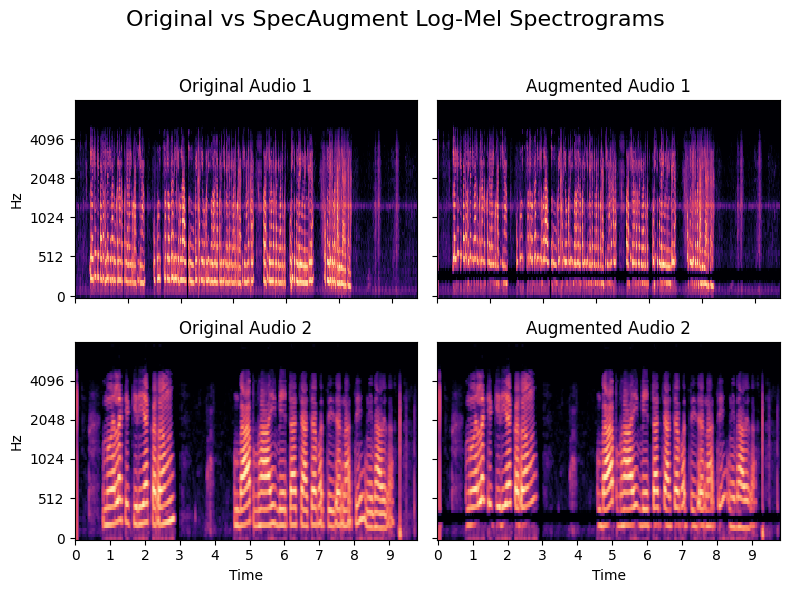

Total duration after augmentation: 403.60 minutes
Total dataset size (after augmentation): 1268


In [24]:
# Path to externally prepared trainval split (speaker-disjoint from test set)
train_val_path = DATA_DIR / "trainval"

data = []
total_duration = 0.0

# --------------------------------------------------
# Load audio–text pairs from WAV + TextGrid files
# --------------------------------------------------
# This loop constructs the trainval dataset used for
# fine-tuning and internal validation.
for fname in os.listdir(train_val_path):
    if fname.endswith(".wav"):
        wav_path = os.path.join(train_val_path, fname)
        tg_path = wav_path.replace(".wav", ".TextGrid")

        # Only retain samples with aligned TextGrid annotations
        if os.path.exists(tg_path):
            transcript = extract_transcript_from_textgrid(tg_path)
            waveform = load_audio(wav_path)

            # Compute duration in seconds
            duration = waveform.squeeze(0).shape[-1] / 16000

            # Filter out very short utterances for training stability
            if duration > CONFIG["min_duration_sec"]:
                total_duration += duration
                data.append({
                    "path": wav_path,
                    "transcription": transcript,
                    "audio": {
                        "array": waveform.squeeze().numpy(),
                        "sampling_rate": 16000
                    }
                })

print(f"Total duration before augmentation: {total_duration/60:.2f} minutes")

# --------------------------------------------------
# Apply waveform-level data augmentation (train only)
# --------------------------------------------------
# Augmented samples reuse original transcriptions and
# are appended to the training pool to increase diversity.

if CONFIG["specaugment"]:
    aug_data, duration = augment_data(data, aug_type="specaug")
    plot_spectrogram_side_by_side(data, aug_data, title="SpecAugment")
    data = data + aug_data
    total_duration += duration

if CONFIG["vtlp"]:
    aug_data, duration = augment_data(data, aug_type="vtlp")
    # plot_spectrogram_side_by_side(data, aug_data, title="VTLP")
    data = data + aug_data
    total_duration += duration

if CONFIG["time_stretch"]:
    aug_data, duration = augment_data(data, aug_type="time_stretched")
    plot_spectrogram_side_by_side(data, aug_data, title="Time-Stretch")
    data = data + aug_data
    total_duration += duration

print(f"Total duration after augmentation: {total_duration/60:.2f} minutes")

# --------------------------------------------------
# Internal train/validation split (within trainval)
# --------------------------------------------------
# This split is used only for early stopping and
# checkpoint selection, not for final evaluation.
random.seed(CONFIG["seed"])
random.shuffle(data)


# This changes the training data size as per config
data = data[:int(CONFIG["train_data_size"] * len(data))] # Take smaller sample for initial

print(f"Total dataset size (after augmentation): {len(data)}")

split = int(0.8 * len(data))
train_data = data[:split]
val_data = data[split:]

# Convert to Hugging Face Dataset objects
train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

dataset = DatasetDict({
    "train": train_dataset,
    "val": val_dataset
})



In [25]:
# --------------------------------------------------
# Build KenLM language model (optional)
# --------------------------------------------------
# When enabled, the language model is trained on the
# available ground-truth transcriptions from the
# trainval set and used later for beam search decoding.

if CONFIG["kenlm_build"]:
    ground_truth_data = [
        gt["transcription"] for gt in data
    ]
    build_kenlm_model(ground_truth_data)


## Hugging Face authentication (required)

This notebook loads pretrained models from Hugging Face that require user authentication
(e.g. gated or access-controlled repositories).

To proceed, please authenticate using your own Hugging Face account:
1. Ensure you have a Hugging Face account (free).
2. When prompted, paste a **read-access token** generated from:
   https://huggingface.co/settings/tokens
3. No access token is stored in this notebook or written to disk.

If authentication is not completed, model loading will fail.


In [26]:
from huggingface_hub import notebook_login
notebook_login()

In [29]:
# --------------------------------------------------
# Load model + processor (CTC fine-tuning setup)
# --------------------------------------------------
# This section:
# 1) loads the pretrained backbone (IndicWav2Vec) and its processor,
# 2) optionally extends the tokenizer for Bhojpuri-specific characters,
# 3) optionally initialises a KenLM-powered decoder for evaluation,
# 4) prepares the dataset for CTC training,
# 5) configures and launches the Hugging Face Trainer.

os.environ["WANDB_DISABLED"] = "true"

# IMPORTANT (submission): do not include or reference any hard-coded HF tokens
# os.environ["HF_TOKEN"] = "..."   # remove entirely from the submitted notebook

custom_tokenizer_dir = OUTPUT_DIR / "tokenizer"

# Load pretrained processor + model checkpoint
processor = Wav2Vec2Processor.from_pretrained(CONFIG["model_id"])
model = AutoModelForCTC.from_pretrained(CONFIG["model_id"])

# --------------------------------------------------
# Optional: Tokenizer extension (language-specific adaptation)
# --------------------------------------------------
# If enabled, add Bhojpuri-relevant characters to the tokenizer and
# resize the model output layer to match the updated vocabulary size.

if CONFIG["tokenizer"]:
    old_num_tokens = len(processor.tokenizer)
    print(f"Processor length before token customization: {old_num_tokens}")

    # Print tokenizer tokens (for auditability)
    vocab_dict = processor.tokenizer.get_vocab()
    sorted_vocab = sorted(vocab_dict.items(), key=lambda x: x[1])
    labels = [token for token, idx in sorted_vocab]
    print(f"Tokenizer before customisation: {labels}")

    # ---------------------------------------------------------------------------------------
    # Add characters observed in Bhojpuri transcripts that are missing from the base tokenizer
    # Analysis and code to determine these characters is present in data analysis notbook
    # ----------------------------------------------------------------------------------------
    new_chars = ["ॄ", "ऽ", "ऒ", ","]

    # Add tokens and resize lm_head accordingly
    num_added = processor.tokenizer.add_tokens(new_chars)
    print(f"Added {num_added} new tokens")

    # Recompute labels after token addition
    vocab_dict = processor.tokenizer.get_vocab()
    sorted_vocab = sorted(vocab_dict.items(), key=lambda x: x[1])
    labels = [token for token, idx in sorted_vocab]

    # Resize the model’s output layer to match new vocab size
    new_vocab_size = len(processor.tokenizer)
    new_lm_head = nn.Linear(model.lm_head.in_features, new_vocab_size, bias=True)

    # Copy weights for existing tokens to preserve pretrained knowledge
    with torch.no_grad():
        new_lm_head.weight[:old_num_tokens] = model.lm_head.weight
        new_lm_head.bias[:old_num_tokens] = model.lm_head.bias

    model.lm_head = new_lm_head
    model.config.vocab_size = new_vocab_size

    # Save and reload processor to ensure tokenizer changes persist across reruns
    processor.save_pretrained(custom_tokenizer_dir)
    processor = Wav2Vec2Processor.from_pretrained(custom_tokenizer_dir)

# --------------------------------------------------
# Optional: KenLM decoder initialisation (decoding-level adaptation)
# --------------------------------------------------
# If enabled, construct a CTC beam-search decoder using a prebuilt KenLM model.
# This decoder is used during metric computation (WER) to improve decoding quality.

if CONFIG["kenlm"]:
    arpa_path = "/content/drive/My Drive/ASR/bhojpuri_3gram.arpa"
    kenlm_path = "/content/drive/My Drive/ASR/bhojpuri_3gram.bin"

    vocab_dict = processor.tokenizer.get_vocab()
    sorted_vocab = sorted(vocab_dict.items(), key=lambda x: x[1])
    labels = [token for token, idx in sorted_vocab]

    # Extract unigrams from the ARPA file to support decoder vocabulary constraints
    unigrams = extract_vocab_from_arpa(arpa_path)

    decoder = build_ctcdecoder(
        labels=labels,
        kenlm_model_path=kenlm_path,
        unigrams=unigrams,
        alpha=0.5,   # tuned on validation set
        beta=1.0     # tuned on validation set
    )

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# --------------------------------------------------
# Tokenise / prepare dataset for CTC training
# --------------------------------------------------
# Convert raw audio + transcription into input_values and label IDs.
dataset = dataset.map(prepare_dataset, remove_columns=["path", "transcription", "audio"])

# --------------------------------------------------
# Trainer setup (collation, metrics, optimiser, training args)
# --------------------------------------------------
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)
wer_metric = evaluate.load("wer")

optimizer = AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.01
)

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    gradient_checkpointing=CONFIG["gradient_checkpointing"],
    eval_strategy=CONFIG["eval_strategy"],
    save_strategy=CONFIG["save_strategy"],
    num_train_epochs=CONFIG["num_train_epochs"],
    learning_rate=CONFIG["learning_rate"],
    logging_steps=CONFIG["logging_steps"],
    save_total_limit=CONFIG["save_total_limit"],
    eval_steps=CONFIG["eval_steps"],
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    fp16=CONFIG["fp16"],
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["val"],  # internal validation split (early stopping / best checkpoint)
    tokenizer=processor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, None),  # default scheduler
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# --------------------------------------------------
# Resume training if checkpoints exist
# --------------------------------------------------
# If rerunning the notebook, training can resume from the latest checkpoint.
last_checkpoint = None
if os.path.isdir(CHECKPOINT_DIR):
    checkpoints = [
        os.path.join(CHECKPOINT_DIR, d)
        for d in os.listdir(CHECKPOINT_DIR)
        if d.startswith("checkpoint")
    ]
    if checkpoints:
        last_checkpoint = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]

# Launch training (resume if a checkpoint is found)
trainer.train(resume_from_checkpoint=last_checkpoint)


Processor length before token customization: 68
Tokenizer before customisation: ['<pad>', '<s>', '</s>', '<unk>', '|', 'ँ', 'ं', 'ः', 'अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ए', 'ऐ', 'ऑ', 'ओ', 'औ', 'क', 'ख', 'ग', 'घ', 'ङ', 'च', 'छ', 'ज', 'झ', 'ञ', 'ट', 'ठ', 'ड', 'ढ', 'ण', 'त', 'थ', 'द', 'ध', 'न', 'प', 'फ', 'ब', 'भ', 'म', 'य', 'र', 'ल', 'व', 'श', 'ष', 'स', 'ह', '़', 'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॅ', 'े', 'ै', 'ॉ', 'ो', 'ौ', '्', 'ळ']
Added 4 new tokens


Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

/tmp/ipython-input-2706184185.py:137: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:180: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/backends/cudnn/__init__.py:145: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.

Epoch,Training Loss,Validation Loss,Wer
14,65.802600,209.173920,0.047463
15,65.802600,210.602783,0.045002



PREDICTED: बियाह होये से पहिले अउर होये के बाद खाये पिबे के कुल बेव्सथा होला, अउर ओमे पुड़ी सबजी खीर मिठाई सब कुछ परोसल जाला
REFERENCE: बियाह होये से पहिले अउर होये के बाद खाये पिबे के कुल बेव्सथा होला, अउर ओमे पुड़ी सबजी खीर मिठाई सब कुछ परोसल जाला

PREDICTED: मुअला पर दखिन दिसा में बइठल जाला
REFERENCE: मुअला पर दखिन दिसा में बइठल जाला


/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:180: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(



PREDICTED: बियाह होये से पहिले अउर होये के बाद खाये पिबे के कुल बेव्सथा होला, अउर ओमे पुड़ी सबजी खीर मिठाई सब कुछ परोसल जाला
REFERENCE: बियाह होये से पहिले अउर होये के बाद खाये पिबे के कुल बेव्सथा होला, अउर ओमे पुड़ी सबजी खीर मिठाई सब कुछ परोसल जाला

PREDICTED: मुअला पर दखिन दिसा में बइठल जाला
REFERENCE: मुअला पर दखिन दिसा में बइठल जाला


TrainOutput(global_step=3810, training_loss=6.954838726213911, metrics={'train_runtime': 877.5198, 'train_samples_per_second': 17.333, 'train_steps_per_second': 4.342, 'total_flos': 1.2598408695382852e+19, 'train_loss': 6.954838726213911, 'epoch': 15.0})

In [30]:
import shutil

# --------------------------------------------------
# Cleanup: remove intermediate training checkpoints
# --------------------------------------------------
# This step deletes saved checkpoints after training has completed
# to reduce disk usage. The final trained model and evaluation
# outputs are preserved separately.

shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)


In [31]:
# --------------------------------------------------
# Save final model and processor
# --------------------------------------------------
# IMPORTANT:
# The FINAL_MODEL_DIR should be updated for each experimental variant
# (e.g., different training data sizes, augmentation settings,
# tokenizer extensions, or KenLM integration).
#
# This ensures that models from different runs are stored separately
# and can be traced unambiguously to their corresponding configurations.

trainer.save_model(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)

[]